In [12]:
import numpy as np
import pandas as pd
from scipy import stats
from datetime import datetime, timezone, timedelta
import os

id_dict = {}
path_dict = '/home/kisho_ucl/kisho_ws/warehouse_task_recognition/data/id_dict.txt'
with open(path_dict, "r") as file:
    for line in file:
        key, value = line.strip().split(": ")
        id_dict[int(key)] = int(value)
subid_dict = {value: key for key, value in id_dict.items()}



In [13]:
import torch
from torch.utils.data import Dataset

class IMUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


In [14]:
from copy import deepcopy
import os
import json


class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False
        self.best_state = None
        self.best_epoch = 0

    def __call__(self, epoch, val_loss, model):
        # 初回、または改善したとき
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.best_state = deepcopy(model.state_dict())
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True



In [ ]:
import numpy as np
import preprocess
import importlib
importlib.reload(preprocess)
from preprocess import load_session_trusco, window_split_trusco
from torch.utils.data import DataLoader, random_split
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    pretrain: bool            # SimCLR pretrain
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str             # directory to save results
    seed: int = 0             # random seed


def sample_train_windows_by_rate(X, y, rate, seed):
    if rate >= 1.0:
        return X, y

    rng = np.random.default_rng(seed)
    selected_indices = []

    for class_label in np.unique(y):
        class_indices = np.where(y == class_label)[0]
        if len(class_indices) == 0:
            continue

        sample_size = max(1, int(np.floor(rate * len(class_indices))))
        sample_size = min(sample_size, len(class_indices))
        chosen = rng.choice(class_indices, size=sample_size, replace=False)
        selected_indices.append(chosen)

    if len(selected_indices) == 0:
        return X[:0], y[:0]

    selected_indices = np.sort(np.concatenate(selected_indices))
    return X[selected_indices], y[selected_indices]


def build_loaders_for_subject(
    test_user,
    YDs,
    IDs,
    Hours,
    all_entries,
    config: ExperimentConfig,
    labeling_rate: float = 1.0,
    sampling_seed: int = 0,
):
    if config.model_type == "cnn-linear":
        window_size = 400 * 1
        train_stride = 200 * 1
        test_stride = 400 * 1
    elif config.model_type == "multi-trans":
        window_size = 400 * 10
        train_stride = 400 * 1
        test_stride = 400 * 1
    elif config.model_type == "dct":
        window_size = 400 * 10
        train_stride = 400 * 1
        test_stride = 400 * 1
    elif config.model_type == "dcl":
        window_size = 400 * 10
        train_stride = 400 * 1
        test_stride = 400 * 1
    else:
        raise ValueError(f"Unknown model_type: {config.model_type}")

    X_train, y_train = [], []
    X_test, y_test = [], []
    train_subject_data = {}

    for Year, Date in YDs:
        for ID in IDs:
            for h in Hours:
                if h not in all_entries or ID not in all_entries[h]:
                    continue

                imu, labels = load_session_trusco(ID, Year, Date, h)
                if imu is None:
                    continue

                if ID == test_user:
                    X, y = window_split_trusco(
                        imu,
                        labels,
                        window_size=window_size,
                        stride=test_stride,
                    )
                    valid = (y != -1)
                    X_test.append(X[valid])
                    y_test.append(y[valid])
                else:
                    X, y = window_split_trusco(
                        imu,
                        labels,
                        window_size=window_size,
                        stride=train_stride,
                    )
                    valid = (y != -1)
                    X = X[valid]
                    y = y[valid]

                    if ID not in train_subject_data:
                        train_subject_data[ID] = {"X": [], "y": []}

                    train_subject_data[ID]["X"].append(X)
                    train_subject_data[ID]["y"].append(y)

    for ID in sorted(train_subject_data.keys()):
        if len(train_subject_data[ID]["X"]) == 0:
            continue

        X_id = np.concatenate(train_subject_data[ID]["X"])
        y_id = np.concatenate(train_subject_data[ID]["y"])
        X_id, y_id = sample_train_windows_by_rate(X_id, y_id, labeling_rate, sampling_seed)

        if len(X_id) == 0:
            continue

        X_train.append(X_id)
        y_train.append(y_id)

    if len(X_train) == 0:
        raise ValueError(f"No train samples available for test_user={test_user}, rate={labeling_rate}")
    if len(X_test) == 0:
        raise ValueError(f"No test samples available for test_user={test_user}")

    X_train = np.concatenate(X_train)
    y_train = np.concatenate(y_train)
    X_test = np.concatenate(X_test)
    y_test = np.concatenate(y_test)

    train_dataset = IMUDataset(X_train, y_train)
    test_dataset = IMUDataset(X_test, y_test)

    train_len = int(len(train_dataset) * (1 - 0.1))
    valid_len = len(train_dataset) - train_len

    train_ds, valid_ds = random_split(
        train_dataset,
        [train_len, valid_len],
        generator=torch.Generator().manual_seed(config.seed),
    )

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    print(
        f"[test_user={test_user} | rate={labeling_rate:.2f}] "
        f"Train={len(train_ds)}, Valid={len(valid_ds)}, Test={len(test_dataset)}"
    )

    return train_loader, valid_loader, test_loader


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
import os
import json


device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

def compute_class_weights(train_loader, num_classes):
    counts = torch.zeros(num_classes)

    for _, labels in train_loader:
        for c in range(num_classes):
            counts[c] += (labels == c).sum()

    total = counts.sum()
    counts[counts == 0] = 1  # 0割回避
    weights = total / (num_classes * counts)
    
    return weights                                                                                                                                                                                                                                                                               


# Train one epoch
def train_one_epoch(classifier, loader, optimizer, criterion):
    classifier.train()
    total_loss = 0
    total_n = 0

    for signals, labels in loader:
        signals = signals.to(device)
        labels  = labels.to(device)

        logits = classifier(signals)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        total_n    += len(labels)

    return total_loss / total_n



# Evaluate
def evaluate(classifier, loader, criterion=None):
    classifier.eval()
    total_loss = 0
    total_n = 0

    Y, P = [], []

    with torch.no_grad():
        for signals, labels in loader:
            signals = signals.to(device)
            labels  = labels.to(device)

            logits = classifier(signals)
            preds  = logits.argmax(dim=1)

            Y.extend(labels.cpu().numpy())
            P.extend(preds.cpu().numpy())

            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * len(labels)
                total_n    += len(labels)

    if criterion is None:
        return Y, P, None
    else:
        return Y, P, total_loss / total_n

def record_results(test_user, y_true, y_pred,
                           results_dir="results_loso"):
    os.makedirs(results_dir, exist_ok=True)
    save_path = os.path.join(results_dir, f"{test_user}.json")

    result = {
        "user": test_user,
        "y_true": list(map(int, y_true)),
        "y_pred": list(map(int, y_pred))
    }
    with open(save_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"Saved: {save_path}")


In [17]:
import models
importlib.reload(models)
from models import SimCLR_new, CNN_Encoder, TaskClassifier_Transformer, TaskClassifier_LSTM, TaskClassifier_Linear, TaskClassifier_DCL, TaskClassifier_DCT
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    #pretrain: bool            # SimCLR pretrain
    pretrain_type: str   # "none", "csshar", "mysimclr", "mysimclr2"
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str             # directory to save results
    seed: int = 0             # random seed

def build_model(config: ExperimentConfig):
    """
    config.model_type : "cnn-linear" or "multi-trans"
    config.pretrain   : True/False
    config.frozen     : True/False
    """

    # # --- 1. Encoder 作成 ---
    # if config.pretrain:
    #     sim = SimCLR_new(input_dim=6, seq_len=400, hidden_dim=64, feature_dim=128, projection_dim=64,feedforward_dim=256, num_layers=2,num_heads=4)
    #     sim.load_state_dict(torch.load(
    #         #"/home/kisho_ucl/kisho_ws/deep_HAR/trusco/experiments/model/0511/imu_encoder_100.pth",
    #         #"/home/kisho_ucl/kisho_ws/deep_HAR/trusco/experiments/model/1212/imu_encoder_100.pth",
    #         #"/home/kisho_ucl/kisho_ws/deep_HAR/trusco/experiments/model/1214/imu_encoder_100.pth", #mysimclr2
    #         "/home/kisho_ucl/kisho_ws/deep_HAR/trusco/experiments/model/0413/imu_encoder_100.pth",
    #         map_location="cpu"
    #     ))
    #     encoder = sim.encoder
    #     print("Loaded pretrained encoder.")
    # else:
    #     encoder = CNN_Encoder(input_dim=6, seq_len=400, hidden_dim=64, feature_dim=128,dropout=0.3)
    #     print("Created new encoder.")

    # --- 1. Encoder 作成 ---
    if config.pretrain_type == "None":
        encoder = CNN_Encoder(
            input_dim=6,
            seq_len=400,
            hidden_dim=64,
            feature_dim=128,
            dropout=0.3
        )
        print("Created new encoder.")

    else:
        sim = SimCLR_new(
            input_dim=6,
            seq_len=400,
            hidden_dim=64,
            feature_dim=128,
            projection_dim=64,
            feedforward_dim=256,
            num_layers=2,
            num_heads=4
        )

        # ===== モデルごとのパス分岐 =====
        if config.pretrain_type == "csshar":
            path = "/home/kisho_ucl/kisho_ws/deep_HAR/trusco/experiments/model/1214/imu_encoder_100.pth"

        elif config.pretrain_type == "mysimclr":
            path = "/home/kisho_ucl/kisho_ws/deep_HAR/trusco/experiments/model/0413/imu_encoder_100.pth"

        elif config.pretrain_type == "mysimclr2":
            #path = "/home/kisho_ucl/kisho_ws/deep_HAR/trusco/experiments/model/0414/imu_encoder_100.pth"
            path = "/home/kisho_ucl/kisho_ws/deep_HAR/trusco/experiments/model/1212/imu_encoder_100.pth"

        else:
            raise ValueError(f"Unknown pretrain_type: {config.pretrain_type}")

        sim.load_state_dict(torch.load(path, map_location="cpu"))
        encoder = sim.encoder

        print(f"Loaded pretrained encoder: {config.pretrain_type}")

    # --- Freeze設定 ---
    if config.frozen:
        for p in encoder.parameters():
            p.requires_grad = False

        print("Encoder is frozen.")
    else:
        print("Encoder is trainable.")

    # --- 2. Model selection ---
    print(f"Building model: {config.model_type}")
    if config.model_type == "cnn-linear":
        model = TaskClassifier_Linear(   # ← linear head なら別クラスでもOK
            encoder=encoder,
            feature_dim=128,
            hidden_dim=64,
            num_classes=3,
            dropout=0.1,
            freeze_encoder=config.frozen
        )
        return model

    elif config.model_type == "multi-trans":
        model = TaskClassifier_Transformer(
            encoder=encoder,
            hidden_dim=128,
            window_len=400,
            overlap=0.5,
            num_heads=4,
            num_layers=3,
            num_classes=3,
            freeze_encoder=config.frozen
        )
        return model
    
    elif config.model_type == "dcl":
        model = TaskClassifier_DCL(
            input_dim=6,
            hidden_dim=64,
            feature_dim=128,
            lstm_hidden=128,
            num_layers=2,
            num_classes=3,
            dropout=0.1,
        )
        return model
    
    elif config.model_type == "dct":
        model = TaskClassifier_DCT(
            input_dim=6,
            hidden_dim=64,
            feature_dim=128,
            num_heads=4,
            num_layers=3,
            num_classes=3,
            dropout=0.1,
        )
        return model

    else:
        raise ValueError(f"Unknown model_type: {config.model_type}")
    
def build_optimizer(model, config: ExperimentConfig):

    # =============================
    # 1. encoder を固定する場合
    # =============================
    if config.frozen:
        print("Optimizer: frozen encoder → uniform LR 1e-3")
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.Adam(params, lr=1e-3)
    
    if config.lr_type == "none":
        print("Optimizer: frozen encoder → uniform LR 1e-3")
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.Adam(params, lr=1e-3)


    # =============================
    # 2. uniform LR
    # =============================
    if config.lr_type == "uniform":
        print("Optimizer: uniform lr=1e-3")
        return torch.optim.Adam(model.parameters(), lr=1e-3)


    # =============================
    # 3. layer-wise LR
    # =============================
    elif config.lr_type == "layerwise":

        encoder_lr = 1e-4
        head_lr = 1e-3

        if isinstance(model, TaskClassifier_Transformer):
            print("Optimizer: layerwise (Transformer)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.transformer.parameters(),  "lr": head_lr}, #out weight decay
                {"params": model.classifier.parameters(),   "lr": head_lr},
            ])

        elif isinstance(model, TaskClassifier_LSTM):
            print("Optimizer: layerwise (LSTM)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.lstm.parameters(),         "lr": head_lr}, # out weight decay
                {"params": model.classifier.parameters(),   "lr": head_lr},
            ])
        elif isinstance(model, TaskClassifier_Linear):
            print("Optimizer: layerwise (Linear)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.classifier.parameters(),   "lr": head_lr}, # out weight decay
            ])
        else:
            raise ValueError("Unknown model architecture for layerwise LR")

    else:
        raise ValueError(f"Unknown lr_type {config.lr_type}")




In [18]:
import models
importlib.reload(models)
from models import SimCLR_new, CNN_Encoder, TaskClassifier_Transformer, TaskClassifier_LSTM, TaskClassifier_DCL, TaskClassifier_DCT
from dataclasses import dataclass
import random

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    #pretrain: bool            # SimCLR pretrain
    pretrain_type: str   # "none", "csshar", "mysimclr", "mysimclr2"
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str           # directory to save results
    seed: int = 0             # random seed

# Reset random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# LOSO
def run_loso_one(
        train_loader, valid_loader, test_loader,
        weight_tensor, test_user="UNKNOWN",
        max_epochs=30, patience=5,
        config: ExperimentConfig = None):

    # Set random seed
    set_seed(config.seed)

    # モデル構築
    classifier = build_model(config).to(device)
    optimizer = build_optimizer(classifier, config)

    weight_tensor = weight_tensor.to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)


    # Early stopping
    early_stopper = EarlyStopping(patience=patience)

    # Training loop
    for epoch in range(1, max_epochs + 1):

        train_loss = train_one_epoch(classifier, train_loader, optimizer, criterion)
        _, _, valid_loss = evaluate(classifier, valid_loader, criterion)
        Y_tmp, P_tmp, test_loss = evaluate(classifier, test_loader, criterion)
        f1_tmp = f1_score(Y_tmp, P_tmp, average="weighted")

        print(
            f"[Epoch {epoch}/{max_epochs}] "
            f"Train={train_loss:.4f} | "
            f"Valid={valid_loss:.4f} | "
            f"Test={test_loss:.4f} | F1={f1_tmp:.4f}"
        )

        # early stopping check
        early_stopper(epoch, valid_loss, classifier)
        if early_stopper.early_stop:
            print("Early stopping.")
            break

    # Load best model
    classifier.load_state_dict(early_stopper.best_state)

    Y, P, _ = evaluate(classifier, test_loader, criterion)
    final_f1 = f1_score(Y, P, average="weighted")

    print(f"[{test_user}] Final F1 = {final_f1:.4f} | BestEpoch={early_stopper.best_epoch}")

    record_results(test_user, Y, P, results_dir=config.save_dir)

    return final_f1, Y, P, classifier

In [19]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

In [ ]:
YDs = [[2024,1003]]
Hours = range(7,18,1)
IDs = range(0,39,1)

all_entries = {
    8: [1],
    9: [21],
    10: [13],
    11: [2, 6, 9, 23, 27, 36, 16],
}

configs = [

    #ExperimentConfig("cnn-linear", "None", False, "uniform", "T1_cnn", ""),
    ExperimentConfig("cnn-linear", "mysimclr2", True, "uniform", "T3_precnn_adj", ""),

    #ExperimentConfig("dcl", "None", False, "uniform", "T4_dcl", ""),


    #ExperimentConfig("multi-trans", "None", False, "uniform", "T5_cnn-transformer", ""),
    #ExperimentConfig("multi-trans", "mysimclr2", True, "uniform", "T7_precnn-transformer_adj", ""),
]

seeds = [0]
labeling_rates = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00]
#labeling_rates = [0.75, 1.00] # デバッグ用に極端な3点だけにする
#sampling_seed = 0
results_root = "trusco_exp/results_loso_rate"
num_classes = 3

all_records = []

for seed in seeds:
    print(f"\n=========== SEED {seed} ===========")
    seed_records = []
    sampling_seed = seed

    for rate in labeling_rates:
        print(f"\n----- Labeling rate: {rate:.2f} -----")
        rate_records = []

        for cfg in configs:
            cfg.seed = seed
            model_name = os.path.basename(cfg.base_dir.rstrip("/"))

            print("===================================")
            print(f" Variant: {model_name}")
            print("===================================")

            for test_hour, subjects in all_entries.items():
                for test_subject in subjects:
                    set_seed(seed)

                    train_loader, valid_loader, test_loader = build_loaders_for_subject(
                        test_user=test_subject,
                        YDs=YDs,
                        IDs=IDs,
                        Hours=Hours,
                        all_entries=all_entries,
                        labeling_rate=rate,
                        sampling_seed=sampling_seed,
                        config=cfg,
                    )

                    weight_tensor = compute_class_weights(train_loader, num_classes)
                    print("Class weights:", weight_tensor.numpy())

                    save_dir = os.path.join(
                        results_root,
                        f"seed{seed}",
                        f"rate{int(rate * 100):03d}",
                        model_name,
                    )
                    os.makedirs(save_dir, exist_ok=True)
                    cfg.save_dir = save_dir

                    f1, Y, P, classifier = run_loso_one(
                        train_loader,
                        valid_loader,
                        test_loader,
                        weight_tensor,
                        test_user=test_subject,
                        max_epochs=30,
                        patience=5,
                        config=cfg,
                    )

                    record = {
                        "seed": seed,
                        "rate": rate,
                        "model": model_name,
                        "test_hour": test_hour,
                        "test_subject": test_subject,
                        "f1": float(f1),
                    }
                    rate_records.append(record)
                    seed_records.append(record)
                    all_records.append(record)
                    print(f"Seed={seed}, Rate={rate:.2f}, User={test_subject}, F1={f1:.4f}")

        if len(rate_records) == 0:
            continue

        rate_df = pd.DataFrame(rate_records)
        rate_summary_df = (
            rate_df.groupby("model", as_index=False)
            .agg(mean_f1=("f1", "mean"), std_f1=("f1", "std"), n_folds=("f1", "size"))
            .sort_values("model")
        )
        rate_summary_df["std_f1"] = rate_summary_df["std_f1"].fillna(0.0)

        display(rate_summary_df)

        rate_dir = os.path.join(results_root, f"seed{seed}", f"rate{int(rate * 100):03d}")
        os.makedirs(rate_dir, exist_ok=True)
        rate_df.to_csv(os.path.join(rate_dir, "fold_results.csv"), index=False)
        rate_summary_df.to_csv(os.path.join(rate_dir, "summary.csv"), index=False)

    if len(seed_records) > 0:
        all_df = pd.DataFrame(seed_records)
        seed_summary_df = (
            all_df.groupby(["rate", "model"], as_index=False)
            .agg(mean_f1=("f1", "mean"), std_f1=("f1", "std"), n_folds=("f1", "size"))
            .sort_values(["rate", "model"])
        )
        seed_summary_df["std_f1"] = seed_summary_df["std_f1"].fillna(0.0)
        seed_dir = os.path.join(results_root, f"seed{seed}")
        os.makedirs(seed_dir, exist_ok=True)
        all_df.to_csv(os.path.join(seed_dir, "all_fold_results.csv"), index=False)
        seed_summary_df.to_csv(os.path.join(seed_dir, "seed_summary.csv"), index=False)
        display(seed_summary_df)



=========== SEED 0 ===========

----- Labeling rate: 0.01 -----
 Variant: T3_precnn_adj
[test_user=1 | rate=0.01] Train=87, Valid=10, Test=582
Class weights: [0.7837838 1.074074  1.2608696]
Loaded pretrained encoder: mysimclr2
Encoder is frozen.
Building model: cnn-linear
Optimizer: frozen encoder → uniform LR 1e-3
[Epoch 1/30] Train=1.0878 | Valid=1.1294 | Test=1.0675 | F1=0.3379
[Epoch 2/30] Train=1.0496 | Valid=1.1291 | Test=1.0324 | F1=0.5784
[Epoch 3/30] Train=1.0133 | Valid=1.1386 | Test=1.0028 | F1=0.5979
[Epoch 4/30] Train=0.9772 | Valid=1.1403 | Test=0.9720 | F1=0.5977
[Epoch 5/30] Train=0.9528 | Valid=1.1159 | Test=0.9393 | F1=0.5983
[Epoch 6/30] Train=0.9284 | Valid=1.0790 | Test=0.9091 | F1=0.6028
[Epoch 7/30] Train=0.9190 | Valid=1.0779 | Test=0.8859 | F1=0.6100
[Epoch 8/30] Train=0.9252 | Valid=1.0814 | Test=0.8707 | F1=0.5934
[Epoch 9/30] Train=0.8984 | Valid=1.1243 | Test=0.8647 | F1=0.5997
[Epoch 10/30] Train=0.8770 | Valid=1.1760 | Test=0.8631 | F1=0.6078
[Epoch 11/3

,model,mean_f1,std_f1,n_folds
0,T3_precnn_adj,0.632018,0.204286,10



----- Labeling rate: 0.05 -----
 Variant: T3_precnn_adj
[test_user=1 | rate=0.05] Train=445, Valid=50, Test=582
Class weights: [0.6931464 1.1323155 1.4833333]
Loaded pretrained encoder: mysimclr2
Encoder is frozen.
Building model: cnn-linear
Optimizer: frozen encoder → uniform LR 1e-3
[Epoch 1/30] Train=1.0065 | Valid=0.8659 | Test=0.9304 | F1=0.6276
[Epoch 2/30] Train=0.8705 | Valid=0.7564 | Test=0.7979 | F1=0.6155
[Epoch 3/30] Train=0.8232 | Valid=0.6695 | Test=0.7779 | F1=0.5951
[Epoch 4/30] Train=0.7572 | Valid=0.6204 | Test=0.7724 | F1=0.6018
[Epoch 5/30] Train=0.7308 | Valid=0.6009 | Test=0.7484 | F1=0.6303
[Epoch 6/30] Train=0.7203 | Valid=0.5734 | Test=0.7548 | F1=0.6054
[Epoch 7/30] Train=0.6846 | Valid=0.5335 | Test=0.7565 | F1=0.6103
[Epoch 8/30] Train=0.6874 | Valid=0.5323 | Test=0.7685 | F1=0.6110
[Epoch 9/30] Train=0.6650 | Valid=0.5124 | Test=0.7635 | F1=0.6161
[Epoch 10/30] Train=0.6496 | Valid=0.5091 | Test=0.7564 | F1=0.6106
[Epoch 11/30] Train=0.6287 | Valid=0.5026 

,model,mean_f1,std_f1,n_folds
0,T3_precnn_adj,0.760878,0.135581,10



----- Labeling rate: 0.10 -----
 Variant: T3_precnn_adj
[test_user=1 | rate=0.10] Train=900, Valid=101, Test=582
Class weights: [0.7352941 1.0563381 1.4423077]
Loaded pretrained encoder: mysimclr2
Encoder is frozen.
Building model: cnn-linear
Optimizer: frozen encoder → uniform LR 1e-3
[Epoch 1/30] Train=0.9489 | Valid=0.8496 | Test=0.8015 | F1=0.6168
[Epoch 2/30] Train=0.8069 | Valid=0.8165 | Test=0.7727 | F1=0.6163
[Epoch 3/30] Train=0.7376 | Valid=0.7736 | Test=0.7693 | F1=0.6256
[Epoch 4/30] Train=0.7184 | Valid=0.7267 | Test=0.8021 | F1=0.6254
[Epoch 5/30] Train=0.6937 | Valid=0.7239 | Test=0.7875 | F1=0.6256
[Epoch 6/30] Train=0.7098 | Valid=0.6999 | Test=0.8454 | F1=0.6150
[Epoch 7/30] Train=0.6639 | Valid=0.6951 | Test=0.8145 | F1=0.6274
[Epoch 8/30] Train=0.6554 | Valid=0.6889 | Test=0.8112 | F1=0.6247
[Epoch 9/30] Train=0.6324 | Valid=0.6864 | Test=0.7998 | F1=0.6317
[Epoch 10/30] Train=0.6370 | Valid=0.6495 | Test=0.8289 | F1=0.6175
[Epoch 11/30] Train=0.6374 | Valid=0.6530

...


----- Labeling rate: 0.75 -----
 Variant: T3_precnn_adj
[test_user=1 | rate=0.75] Train=6813, Valid=757, Test=582
Class weights: [0.71776235 1.0717319  1.4843137 ]
Loaded pretrained encoder: mysimclr2
Encoder is frozen.
Building model: cnn-linear
Optimizer: frozen encoder → uniform LR 1e-3
[Epoch 1/30] Train=0.7568 | Valid=0.6454 | Test=0.8045 | F1=0.6300
[Epoch 2/30] Train=0.6316 | Valid=0.5837 | Test=0.8282 | F1=0.6306
[Epoch 3/30] Train=0.5968 | Valid=0.5805 | Test=0.8484 | F1=0.6293
[Epoch 4/30] Train=0.5769 | Valid=0.5572 | Test=0.9084 | F1=0.6103
[Epoch 5/30] Train=0.5680 | Valid=0.5575 | Test=0.8571 | F1=0.6062
[Epoch 6/30] Train=0.5542 | Valid=0.5314 | Test=0.8684 | F1=0.6357
[Epoch 7/30] Train=0.5428 | Valid=0.5480 | Test=0.9489 | F1=0.6161
[Epoch 8/30] Train=0.5335 | Valid=0.5498 | Test=0.9244 | F1=0.6438
[Epoch 9/30] Train=0.5309 | Valid=0.5236 | Test=0.8786 | F1=0.6439
[Epoch 10/30] Train=0.5281 | Valid=0.5165 | Test=0.8852 | F1=0.6432
[Epoch 11/30] Train=0.5180 | Valid=0.

,model,mean_f1,std_f1,n_folds
0,T3_precnn_adj,0.784456,0.117116,10



----- Labeling rate: 1.00 -----
 Variant: T3_precnn_adj
[test_user=1 | rate=1.00] Train=9090, Valid=1011, Test=582
Class weights: [0.71310896 1.0887531  1.4723032 ]
Loaded pretrained encoder: mysimclr2
Encoder is frozen.
Building model: cnn-linear
Optimizer: frozen encoder → uniform LR 1e-3
[Epoch 1/30] Train=0.7165 | Valid=0.6101 | Test=0.8288 | F1=0.6081
[Epoch 2/30] Train=0.6074 | Valid=0.5546 | Test=0.8375 | F1=0.6357
[Epoch 3/30] Train=0.5782 | Valid=0.5273 | Test=0.8318 | F1=0.6416
[Epoch 4/30] Train=0.5607 | Valid=0.5211 | Test=0.9110 | F1=0.6294
[Epoch 5/30] Train=0.5532 | Valid=0.4968 | Test=0.9217 | F1=0.6313
[Epoch 6/30] Train=0.5438 | Valid=0.5044 | Test=0.8862 | F1=0.6466
[Epoch 7/30] Train=0.5440 | Valid=0.5013 | Test=0.9841 | F1=0.6495
[Epoch 8/30] Train=0.5247 | Valid=0.4738 | Test=0.9309 | F1=0.6616
[Epoch 9/30] Train=0.5284 | Valid=0.4591 | Test=0.8819 | F1=0.6449
[Epoch 10/30] Train=0.5326 | Valid=0.4583 | Test=0.9250 | F1=0.6410
[Epoch 11/30] Train=0.5205 | Valid=0

,model,mean_f1,std_f1,n_folds
0,T3_precnn_adj,0.788885,0.111321,10


,rate,model,mean_f1,std_f1,n_folds
0,0.01,T3_precnn_adj,0.632018,0.204286,10
1,0.05,T3_precnn_adj,0.760878,0.135581,10
2,0.10,T3_precnn_adj,0.764185,0.136023,10
3,0.25,T3_precnn_adj,0.789161,0.122342,10
4,0.50,T3_precnn_adj,0.799441,0.112554,10
5,0.75,T3_precnn_adj,0.784456,0.117116,10
6,1.00,T3_precnn_adj,0.788885,0.111321,10


,model,rate,mean_score,std_score,n_runs,train_percent
0,T1_cnn,0.01,0.517459,0.296951,40,1.0
1,T1_cnn,0.05,0.592281,0.274886,40,5.0
2,T1_cnn,0.10,0.630240,0.278816,40,10.0
3,T1_cnn,0.25,0.640866,0.272562,40,25.0
4,T1_cnn,0.50,0.674575,0.268707,40,50.0
5,T1_cnn,0.75,0.674093,0.263622,40,75.0
6,T1_cnn,1.00,0.678189,0.245012,40,100.0
7,T3_precnn_adj,0.01,0.632959,0.229904,40,1.0
8,T3_precnn_adj,0.05,0.703999,0.150246,40,5.0
9,T3_precnn_adj,0.10,0.734909,0.152651,40,10.0


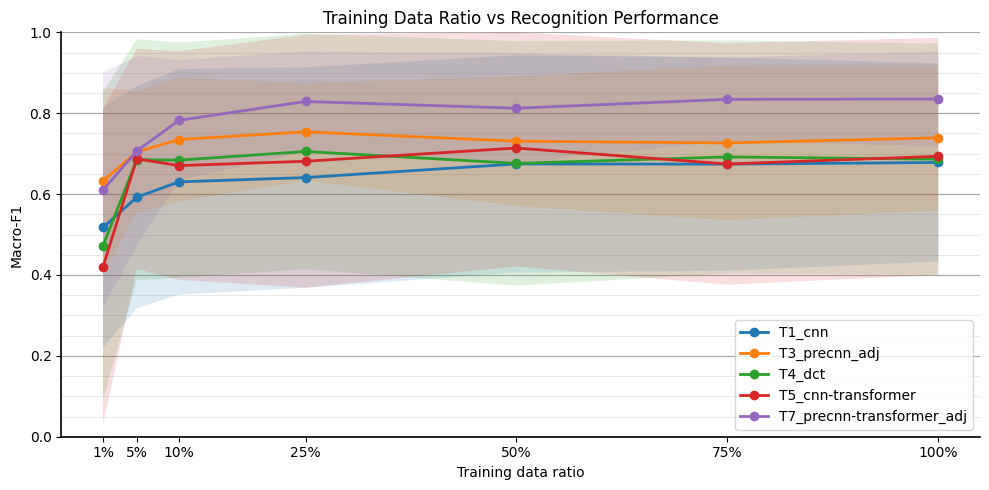

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from IPython.display import display


def collect_rate_results(root_dir="results_loso_rate", average="weighted"):
    rows = []

    def collect_json_scores(model_name, model_dir, rate_value=None, seed_name=None):
        for fname in sorted(os.listdir(model_dir)):
            if not fname.endswith(".json"):
                continue

            json_path = os.path.join(model_dir, fname)
            with open(json_path, "r") as fp:
                record = json.load(fp)

            y_true = np.array(record["y_true"])
            y_pred = np.array(record["y_pred"])
            rows.append(
                {
                    "seed": seed_name,
                    "rate": rate_value,
                    "model": model_name,
                    "subject": int(record.get("user", fname.replace(".json", ""))),
                    "score": float(f1_score(y_true, y_pred, average=average)),
                }
            )

    for entry_name in sorted(os.listdir(root_dir)):
        entry_dir = os.path.join(root_dir, entry_name)
        if not os.path.isdir(entry_dir):
            continue

        if entry_name.startswith("seed"):
            for rate_name in sorted(os.listdir(entry_dir)):
                rate_dir = os.path.join(entry_dir, rate_name)
                if not os.path.isdir(rate_dir) or not rate_name.startswith("rate"):
                    continue

                try:
                    rate_value = int(rate_name.replace("rate", "")) / 100.0
                except ValueError:
                    continue

                for model_name in sorted(os.listdir(rate_dir)):
                    model_dir = os.path.join(rate_dir, model_name)
                    if os.path.isdir(model_dir):
                        collect_json_scores(model_name, model_dir, rate_value=rate_value, seed_name=entry_name)
        else:
            collect_json_scores(entry_name, entry_dir)

    return pd.DataFrame(rows)


results_root_candidates = ["results_loso_rate", "results_loso_rate"]
results_root = next((path for path in results_root_candidates if os.path.isdir(path)), None)
if results_root is None:
    raise FileNotFoundError("Could not find results_loso_rate directory")

score_df = collect_rate_results(results_root, average="weighted")

if score_df.empty:
    raise ValueError(f"No results found under: {results_root}")

has_rate_values = score_df["rate"].notna().any()

if has_rate_values:
    summary_df = (
        score_df.groupby(["model", "rate"], as_index=False)
        .agg(
            mean_score=("score", "mean"),
            std_score=("score", "std"),
            n_runs=("score", "size"),
        )
        .sort_values(["model", "rate"])
    )
    summary_df["std_score"] = summary_df["std_score"].fillna(0.0)
    summary_df["train_percent"] = summary_df["rate"] * 100.0
else:
    summary_df = (
        score_df.groupby(["model"], as_index=False)
        .agg(
            mean_score=("score", "mean"),
            std_score=("score", "std"),
            n_runs=("score", "size"),
        )
        .sort_values(["model"])
    )
    summary_df["std_score"] = summary_df["std_score"].fillna(0.0)

display(summary_df)

plt.figure(figsize=(10, 5))
ax = plt.gca()

for y in np.arange(0, 1.01, 0.2):
    ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)

for y in np.arange(0, 1.01, 0.05):
    ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

if has_rate_values:
    for model_name, group_df in summary_df.groupby("model"):
        group_df = group_df.sort_values("rate")
        lower = np.clip(group_df["mean_score"] - group_df["std_score"], 0.0, 1.0)
        upper = np.clip(group_df["mean_score"] + group_df["std_score"], 0.0, 1.0)
        plt.fill_between(
            group_df["train_percent"],
            lower,
            upper,
            alpha=0.15,
        )
        plt.plot(
            group_df["train_percent"],
            group_df["mean_score"],
            marker="o",
            linewidth=2,
            label=model_name,
        )

    train_values = sorted(summary_df["train_percent"].unique())
    plt.xticks(train_values, [f"{value:.0f}%" for value in train_values])
    plt.xlabel("Training data ratio")
    plt.title("Training Data Ratio vs Recognition Performance")
    plt.legend()
else:
    x = np.arange(len(summary_df))
    plt.bar(
        x,
        summary_df["mean_score"],
        yerr=summary_df["std_score"],
        capsize=4,
        edgecolor="black",
        linewidth=1.2,
    )
    for xi, mean_score, std_score in zip(x, summary_df["mean_score"], summary_df["std_score"]):
        plt.text(
            xi,
            mean_score + 0.015,
            f"{mean_score:.3f}±{std_score:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    plt.xticks(x, summary_df["model"], rotation=45, ha="right")
    plt.xlabel("Model")
    plt.title("Recognition Performance by Model")

plt.ylim(0.0, 1.0)
plt.ylabel("Macro-F1")
plt.tight_layout()
plt.show()

=== summary_df (std across seeds) ===


,model_disp,rate,mean_score,std_score,n_seeds,mean_runs,train_percent
0,CNN,0.01,0.517459,0.008441,4,10.0,1.0
1,CNN,0.05,0.592281,0.030890,4,10.0,5.0
2,CNN,0.10,0.630240,0.020968,4,10.0,10.0
3,CNN,0.25,0.640866,0.008422,4,10.0,25.0
4,CNN,0.50,0.674575,0.010793,4,10.0,50.0
5,CNN,0.75,0.674093,0.010016,4,10.0,75.0
6,CNN,1.00,0.678189,0.024993,4,10.0,100.0
7,CNN-T,0.01,0.420334,0.062362,4,10.0,1.0
8,CNN-T,0.05,0.687118,0.038655,4,10.0,5.0
9,CNN-T,0.10,0.670478,0.024377,4,10.0,10.0


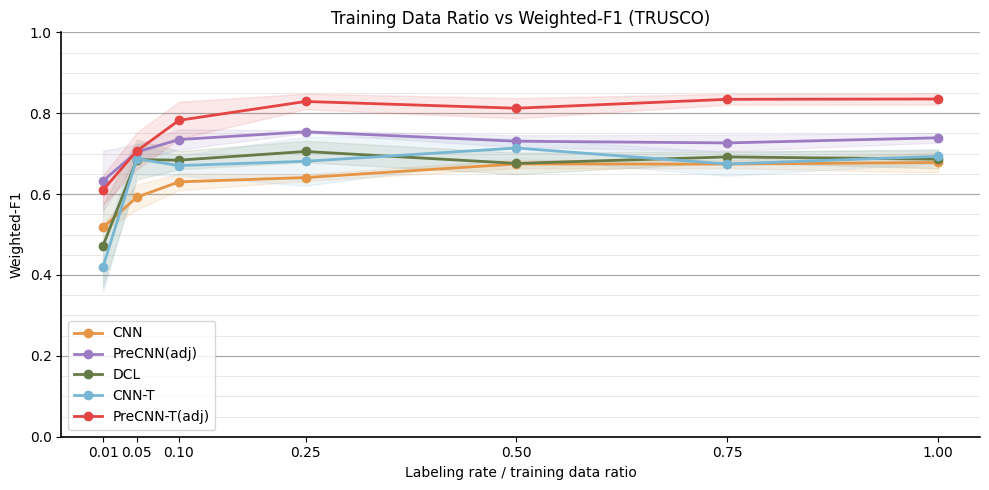

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ここで集計対象の seed を指定
seeds = [0,1,2,3,4]
seed_names = {f"seed{int(s)}" for s in seeds}

score_df_seed = score_df[score_df["seed"].isin(seed_names)].copy()
if score_df_seed.empty:
    raise ValueError(f"No results found for seeds={seeds}")

# モデル名の表示統一（凡例用）
name_map = {
    "T1_cnn": "CNN",
    "T3_precnn_adj": "PreCNN(adj)",
    "T4_dct": "DCL",
    "T5_cnn-transformer": "CNN-T",
    "T7_precnn-transformer_adj": "PreCNN-T(adj)",
}

def normalize_model_name(name: str) -> str:
    raw = str(name).strip()
    if raw in name_map:
        return name_map[raw]
    lower_map = {k.lower(): v for k, v in name_map.items()}
    low = raw.lower()
    if low in lower_map:
        return lower_map[low]
    return raw.replace("(std)", "").replace("_std", "").strip()

score_df_seed["model_disp"] = score_df_seed["model"].map(normalize_model_name)
score_df_seed["seed_id"] = score_df_seed["seed"].str.replace("seed", "", regex=False).astype(int)

# 1) まず seed × model × rate の平均を作る（subject/run の平均）
per_seed_df = (
    score_df_seed.groupby(["seed_id", "model_disp", "rate"], as_index=False)
    .agg(
        seed_score=("score", "mean"),
        n_runs=("score", "size"),
    )
    .sort_values(["seed_id", "model_disp", "rate"])
)

# 2) 次に model × rate で seed 間平均/標準偏差を計算
summary_df = (
    per_seed_df.groupby(["model_disp", "rate"], as_index=False)
    .agg(
        mean_score=("seed_score", "mean"),
        std_score=("seed_score", "std"),
        n_seeds=("seed_id", "nunique"),
        mean_runs=("n_runs", "mean"),
    )
    .sort_values(["model_disp", "rate"])
)

# seeds が1つなら std は NaN になるので 0 にする
summary_df["std_score"] = summary_df["std_score"].fillna(0.0)
summary_df["train_percent"] = summary_df["rate"] * 100.0

print("=== summary_df (std across seeds) ===")
display(summary_df)

# 凡例順と色を固定
model_order = [
    "CNN",
    "PreCNN(adj)",
    "DCL",
    "CNN-T",
    "PreCNN-T(adj)",
]

model_style = {
    "CNN": {"color": "#E69545", "linestyle": "-", "marker": "o"},
    "PreCNN(adj)": {"color": "#9B7CC3", "linestyle": "-", "marker": "o"},
    "DCL": {"color": "#657A44", "linestyle": "-", "marker": "o"},
    "CNN-T": {"color": "#78B7D4", "linestyle": "-", "marker": "o"},
    "PreCNN-T(adj)": {"color": "#E44444", "linestyle": "-", "marker": "o"},
}

plt.figure(figsize=(10, 5))
ax = plt.gca()

# 背景グリッド
for y in np.arange(0, 1.01, 0.2):
    ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
for y in np.arange(0, 1.01, 0.05):
    ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

for model_name in model_order:
    group_df = summary_df[summary_df["model_disp"] == model_name].sort_values("rate")
    if group_df.empty:
        continue

    x = group_df["rate"].to_numpy()
    y = group_df["mean_score"].to_numpy()
    s = group_df["std_score"].to_numpy()

    lower = np.clip(y - s, 0.0, 1.0)
    upper = np.clip(y + s, 0.0, 1.0)

    style = model_style[model_name]
    ax.plot(
        x, y,
        label=model_name,
        color=style["color"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2,
    )
    ax.fill_between(x, lower, upper, color=style["color"], alpha=0.12)

# 未定義モデルがあれば最後に追加表示（色は自動）
known_models = set(model_order)
extra_models = [m for m in summary_df["model_disp"].unique() if m not in known_models]
for model_name in sorted(extra_models):
    group_df = summary_df[summary_df["model_disp"] == model_name].sort_values("rate")
    x = group_df["rate"].to_numpy()
    y = group_df["mean_score"].to_numpy()
    s = group_df["std_score"].to_numpy()
    lower = np.clip(y - s, 0.0, 1.0)
    upper = np.clip(y + s, 0.0, 1.0)
    ax.plot(x, y, marker="o", linewidth=2, label=model_name)
    ax.fill_between(x, lower, upper, alpha=0.12)

rate_values = sorted(summary_df["rate"].unique())
plt.xticks(rate_values, [f"{rate:.2f}" for rate in rate_values])
plt.ylim(0.0, 1.0)
plt.xlabel("Labeling rate / training data ratio")
plt.ylabel("Weighted-F1")
plt.title("Training Data Ratio vs Weighted-F1 (TRUSCO)")
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

In [ ]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score

def compute_weighted_f1(results_dir, num_classes=3):
    files = sorted(os.listdir(results_dir))

    all_y = []
    all_p = []

    for fname in files:
        if not fname.endswith(".json"):
            continue

        with open(os.path.join(results_dir, fname)) as fp:
            res = json.load(fp)

        y_true = np.array(res["y_true"])
        y_pred = np.array(res["y_pred"])

        all_y.extend(y_true)
        all_p.extend(y_pred)

    all_y = np.array(all_y)
    all_p = np.array(all_p)

    f1_weighted = f1_score(all_y, all_p, average="macro")

    return f1_weighted

root = "results_loso"
summary = {}

for exp in sorted(os.listdir(root)):
    exp_dir = os.path.join(root, exp)
    if not os.path.isdir(exp_dir):
        continue

    f1 = compute_weighted_f1(exp_dir)
    summary[exp] = f1

summary
r


NameError: name 'r' is not defined

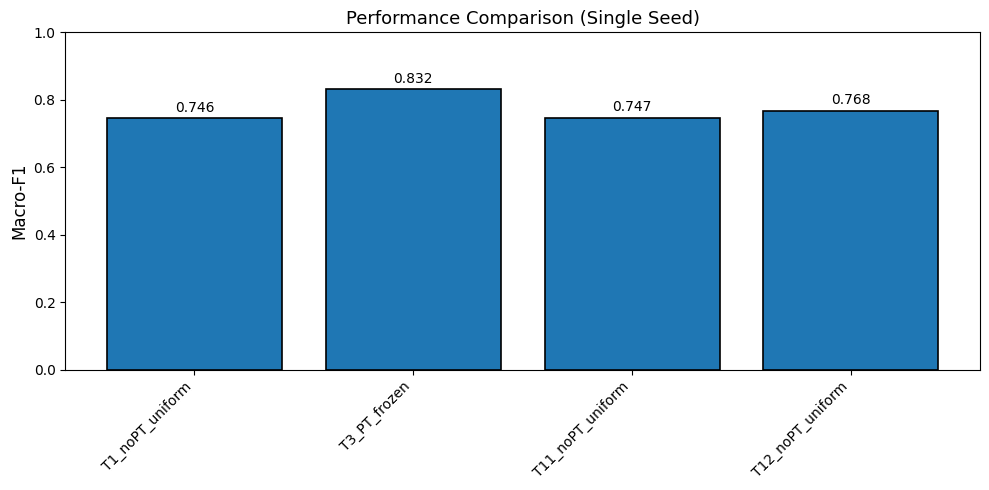

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# summary dict を展開
#variants = list(summary.keys())
variants = [
    "T1_noPT_uniform",
    "T3_PT_frozen",
    #"T4_PT_ft_uniform",
    #"T5_PT_ft_layerwise",
    "T11_noPT_uniform",
    "T12_noPT_uniform"
]
means = [summary[v]for v in variants]
#stds  = [summary[v]["std_f1"] for v in variants]

x = np.arange(len(variants))

plt.figure(figsize=(10, 5))
plt.bar(
    x, means,
    capsize=5,
    edgecolor="black",
    linewidth=1.2
)

# bar 上に数値表示
for xi, m in zip(x, means):
    plt.text(
        xi, m + 0.01,
        f"{m:.3f}",
        ha="center", va="bottom", fontsize=10
    )

plt.xticks(x, variants, rotation=45, ha="right")
plt.ylabel("Macro-F1", fontsize=12)
plt.ylim(0, 1.0)
plt.title("Performance Comparison (Single Seed)", fontsize=13)

plt.tight_layout()
plt.show()
